Total shape: (6653837, 22)
📊 Summary of Wage by Year


,count,mean,std,median
year,,,,
"2,009",55020,"66,170","68,539","63,586"
"2,010",265175,"71,291","62,782","65,220"
"2,011",304293,"79,214","62,662","70,000"
"2,012",318722,"80,944","56,504","71,436"
"2,013",374350,"82,034","42,741","72,300"
"2,014",444071,"83,002","36,568","73,012"
"2,015",185781,"80,239","33,023","71,178"
"2,016",76742,"60,313","34,975","47,580"
"2,017",523723,"57,044","34,861","44,805"


🏢 Summary of Wage by Top Employers


,count,mean,std,median
EMPLOYER_NAME_CLEAN,,,,
infosys,189873,"76,688","26,100","74,443"
tata consultancy services,141811,"85,124","30,647","81,870"
cognizant technology solutions us,127542,"90,559","29,662","90,355"
amazon com services,88236,"140,640","69,847","141,378"
microsoft,87800,"136,185","41,692","137,262"
ernst young u s llp,86846,"122,416","78,173","112,800"
deloitte consulting llp,83899,"94,650","57,071","91,300"
google,82148,"150,858","68,534","151,000"
wipro,62187,"70,225","33,814","71,573"


🌎 Summary by State


,count,mean,std,median
WORKSITE_STATE,,,,
CALIFORNIA,1262346,"119,708","84,813","112,299"
TEXAS,767131,"95,979","78,273","91,562"
NEW YORK,545709,"104,831","83,627","90,000"
NEW JERSEY,409555,"91,765","70,533","84,239"
ILLINOIS,329627,"90,072","77,017","81,000"
WASHINGTON,324970,"122,916","77,254","120,000"
MASSACHUSETTS,256647,"98,835","84,145","90,646"
GEORGIA,241280,"91,369","77,502","85,399"
PENNSYLVANIA,225682,"88,337","74,974","80,000"


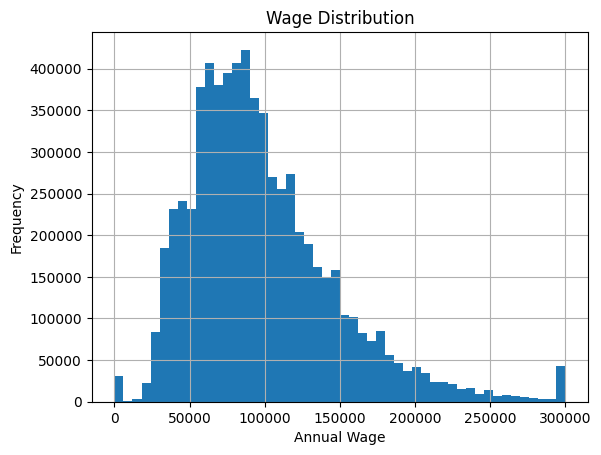

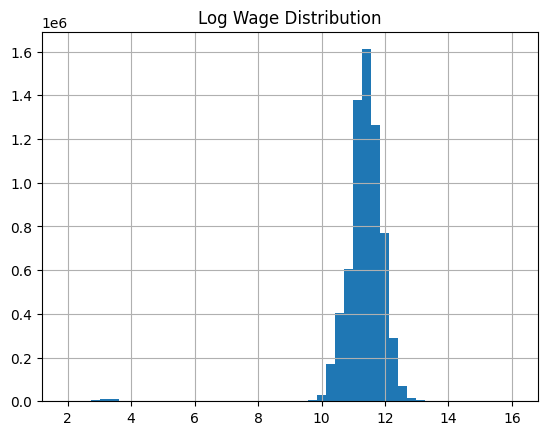

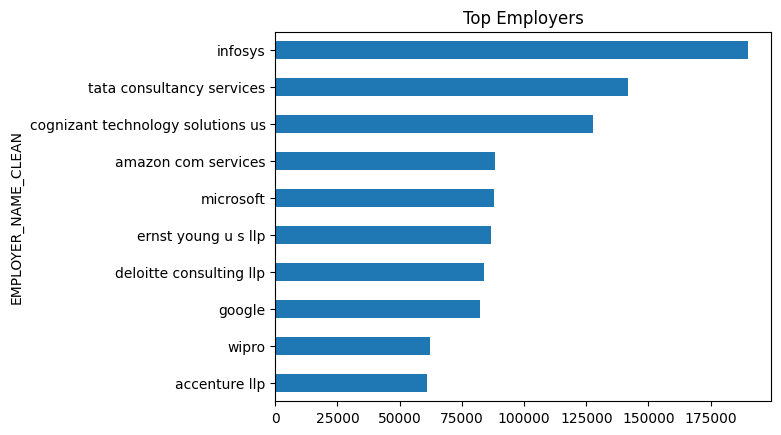

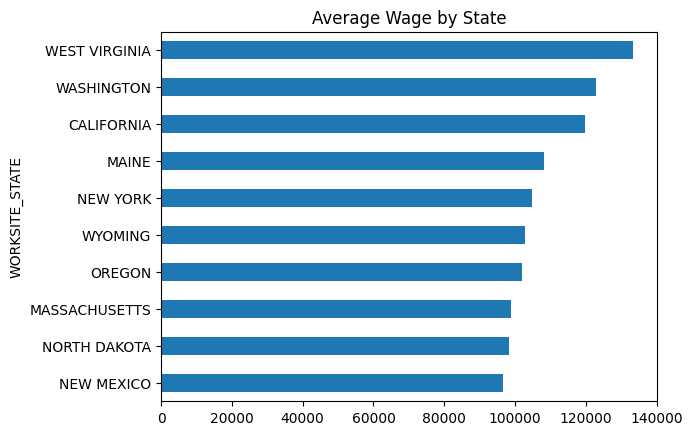

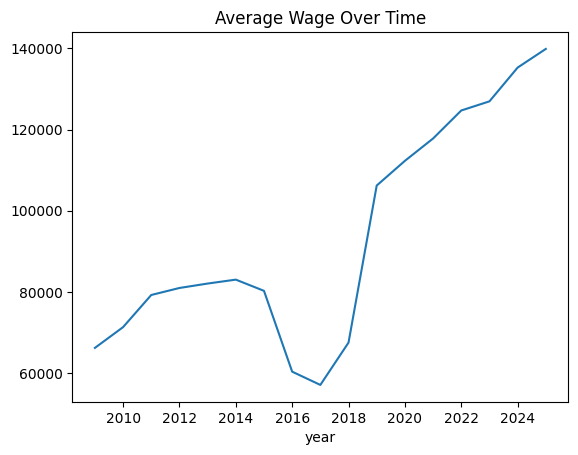

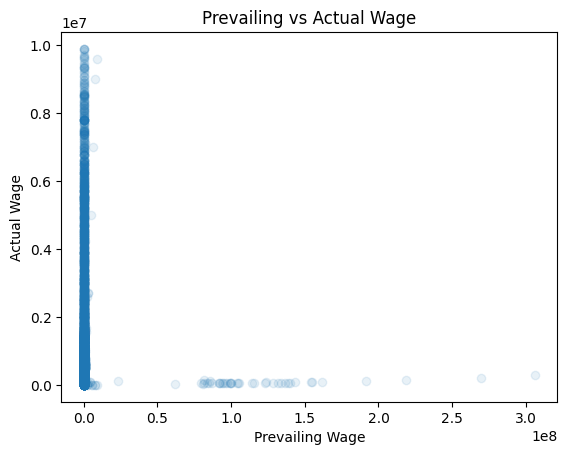

,count,mean,std,median
WORKSITE_STATE,,,,
FM,1,0.57,NaN,0.57
PW,7,0.95,0.31,1.00
MARSHALL ISLANDS,1,1.03,NaN,1.03
GU,5201,1.05,0.99,1.02
NEW JERSEY,409555,1.05,0.68,1.03
VIRGINIA,190443,1.08,0.70,1.04
MINNESOTA,101392,1.09,0.86,1.06
MICHIGAN,186930,1.09,0.72,1.07
MARYLAND,107008,1.10,0.83,1.05


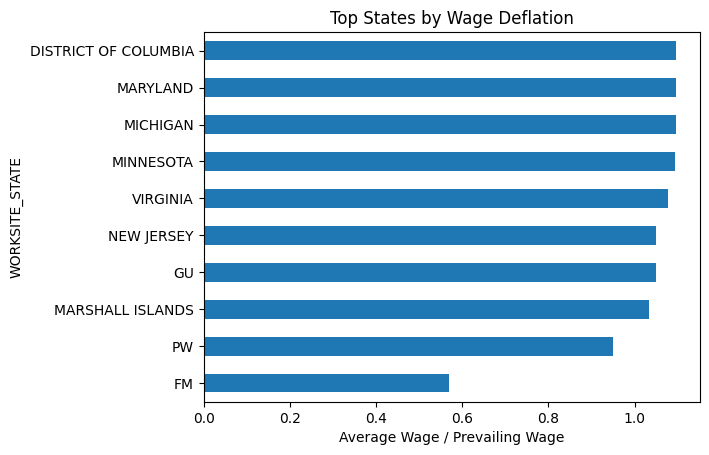

,count,mean,std,median
EMPLOYER_NAME_CLEAN,,,,
tech mahindra americas,37906,0.85,0.32,1.00
capgemini america,46252,0.91,0.54,1.00
wipro,62187,0.95,0.40,1.00
cognizant technology solutions us,127542,0.97,0.22,1.00
ibm india private,32873,1.02,0.37,1.05
infosys,189873,1.02,0.28,1.06
hcl america,48835,1.08,0.27,1.10
larsen toubro infotech,27357,1.09,0.62,1.09
deloitte consulting llp,83899,1.11,0.53,1.11


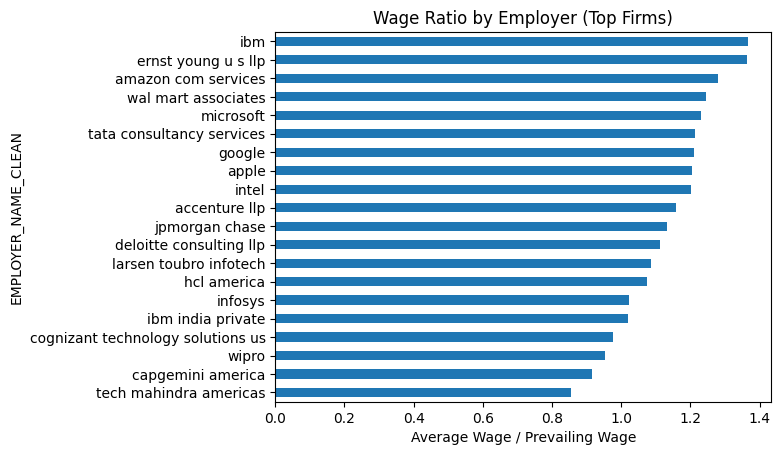

,WORKSITE_STATE,EMPLOYER_NAME_CLEAN,wage_ratio
41,ALABAMA,accenture llp,1.02
188,ALABAMA,amazon com services,1.17
521,ALABAMA,capgemini america,1.13
642,ALABAMA,cognizant technology solutions us,0.96
826,ALABAMA,deloitte consulting llp,1.16


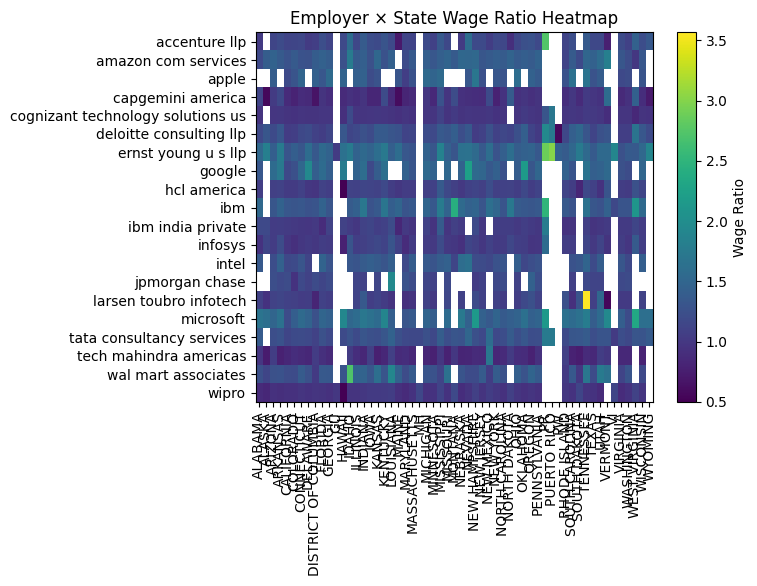

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display

#DATA SUMMARY STATISTICS
state_map = {
    'AL': 'Alabama', 'AK': 'Alaska', 'AZ': 'Arizona', 'AR': 'Arkansas',
    'CA': 'California', 'CO': 'Colorado', 'CT': 'Connecticut', 'DE': 'Delaware',
    'FL': 'Florida', 'GA': 'Georgia', 'HI': 'Hawaii', 'ID': 'Idaho',
    'IL': 'Illinois', 'IN': 'Indiana', 'IA': 'Iowa', 'KS': 'Kansas',
    'KY': 'Kentucky', 'LA': 'Louisiana', 'ME': 'Maine', 'MD': 'Maryland',
    'MA': 'Massachusetts', 'MI': 'Michigan', 'MN': 'Minnesota', 'MS': 'Mississippi',
    'MO': 'Missouri', 'MT': 'Montana', 'NE': 'Nebraska', 'NV': 'Nevada',
    'NH': 'New Hampshire', 'NJ': 'New Jersey', 'NM': 'New Mexico', 'NY': 'New York',
    'NC': 'North Carolina', 'ND': 'North Dakota', 'OH': 'Ohio', 'OK': 'Oklahoma',
    'OR': 'Oregon', 'PA': 'Pennsylvania', 'RI': 'Rhode Island',
    'SC': 'South Carolina', 'SD': 'South Dakota', 'TN': 'Tennessee',
    'TX': 'Texas', 'UT': 'Utah', 'VT': 'Vermont', 'VA': 'Virginia',
    'WA': 'Washington', 'WV': 'West Virginia', 'WI': 'Wisconsin', 'WY': 'Wyoming',
    'DC': 'District of Columbia'
}

df = pd.read_parquet("../data/final_cleaned.parquet")
pd.options.display.float_format = '{:,.0f}'.format
df.WORKSITE_STATE = df.WORKSITE_STATE.map(state_map).fillna(df.WORKSITE_STATE).str.upper()
df = df.dropna(subset=['WAGE_RATE_OF_PAY', 'PREVAILING_WAGE'])  # drop rows with missing wage data
df = df[(df.WAGE_RATE_OF_PAY > 0) & (df.PREVAILING_WAGE > 0)]  # filter out non-positive wages
df = df[df.WAGE_RATE_OF_PAY <10**7]  # filter out likely incorrect wages 
df['log_wage'] = np.log(df['WAGE_RATE_OF_PAY'])
df['wage_ratio'] = df['WAGE_RATE_OF_PAY'] / df['PREVAILING_WAGE']

print("Total shape:", df.shape)
by_year = (
    df.groupby('year')['WAGE_RATE_OF_PAY']
    .agg(['count', 'mean', 'std', 'median'])
    .sort_index()
)
top_employers = df['EMPLOYER_NAME_CLEAN'].value_counts().head(10).index
by_employer = (
    df[df['EMPLOYER_NAME_CLEAN'].isin(top_employers)]
    .groupby('EMPLOYER_NAME_CLEAN')['WAGE_RATE_OF_PAY']
    .agg(['count', 'mean', 'std', 'median'])
    .sort_values('count', ascending=False)
)
by_state = (
    df.groupby('WORKSITE_STATE')['WAGE_RATE_OF_PAY']
    .agg(['count', 'mean', 'std', 'median'])
    .sort_values('count', ascending=False)
)

# round everything nicely
by_year_fmt = by_year.round(2)
by_employer_fmt = by_employer.round(2)
by_state_fmt = by_state.round(2)

print("📊 Summary of Wage by Year")
display(by_year_fmt)

print("🏢 Summary of Wage by Top Employers")
display(by_employer_fmt)

print("🌎 Summary by State")
display(by_state_fmt.head(15))

plt.figure()
df['WAGE_RATE_OF_PAY'].clip(upper=300000).hist(bins=50)
plt.title("Wage Distribution")
plt.xlabel("Annual Wage")
plt.ylabel("Frequency")
plt.show()

plt.figure()
df['log_wage'].hist(bins=50)
plt.title("Log Wage Distribution")
plt.show()

top_emp = df['EMPLOYER_NAME_CLEAN'].value_counts().head(10)

plt.figure()
top_emp.sort_values().plot(kind='barh')
plt.title("Top Employers")
plt.show()

state_wage = df.groupby('WORKSITE_STATE')['WAGE_RATE_OF_PAY'].mean().sort_values(ascending=False).head(10)

plt.figure()
state_wage.sort_values().plot(kind='barh')
plt.title("Average Wage by State")
plt.show()

trend = df.groupby('year')['WAGE_RATE_OF_PAY'].mean()

plt.figure()
trend.plot()
plt.title("Average Wage Over Time")
plt.show()

plt.figure()
plt.scatter(df['PREVAILING_WAGE'], df['WAGE_RATE_OF_PAY'], alpha=0.1)
plt.xlabel("Prevailing Wage")
plt.ylabel("Actual Wage")
plt.title("Prevailing vs Actual Wage")
plt.show()

pd.options.display.float_format = '{:,.2f}'.format

state_ratio = (
    df.groupby('WORKSITE_STATE')['wage_ratio']
    .agg(['count', 'mean', 'std', 'median'])
    .sort_values('mean', ascending=True)
)

display(state_ratio.head(15))

top_states = state_ratio.head(10)

plt.figure()
top_states['mean'].sort_values(ascending=True).plot(kind='barh')
plt.title("Top States by Wage Deflation")
plt.xlabel("Average Wage / Prevailing Wage")
plt.show()

top_emp = df['EMPLOYER_NAME_CLEAN'].value_counts().head(20).index

emp_ratio = (
    df[df['EMPLOYER_NAME_CLEAN'].isin(top_emp)]
    .groupby('EMPLOYER_NAME_CLEAN')['wage_ratio']
    .agg(['count', 'mean', 'std', 'median'])
    .sort_values('mean', ascending=True)
)

display(emp_ratio)

plt.figure()
emp_ratio['mean'].sort_values(ascending=True).plot(kind='barh')
plt.title("Wage Ratio by Employer (Top Firms)")
plt.xlabel("Average Wage / Prevailing Wage")
plt.show()

combo = (
    df.groupby(['WORKSITE_STATE', 'EMPLOYER_NAME_CLEAN'])['wage_ratio']
    .mean()
    .reset_index()
)

# focus on big employers only
combo = combo[combo['EMPLOYER_NAME_CLEAN'].isin(top_emp)]

display(combo.head())

pivot = combo.pivot(index='EMPLOYER_NAME_CLEAN', columns='WORKSITE_STATE', values='wage_ratio')

plt.figure()
plt.imshow(pivot, aspect='auto')
plt.colorbar(label='Wage Ratio')
plt.title("Employer × State Wage Ratio Heatmap")
plt.xticks(range(len(pivot.columns)), pivot.columns, rotation=90)
plt.yticks(range(len(pivot.index)), pivot.index)
plt.show()


Underpayment rate: 0.12960025921885374


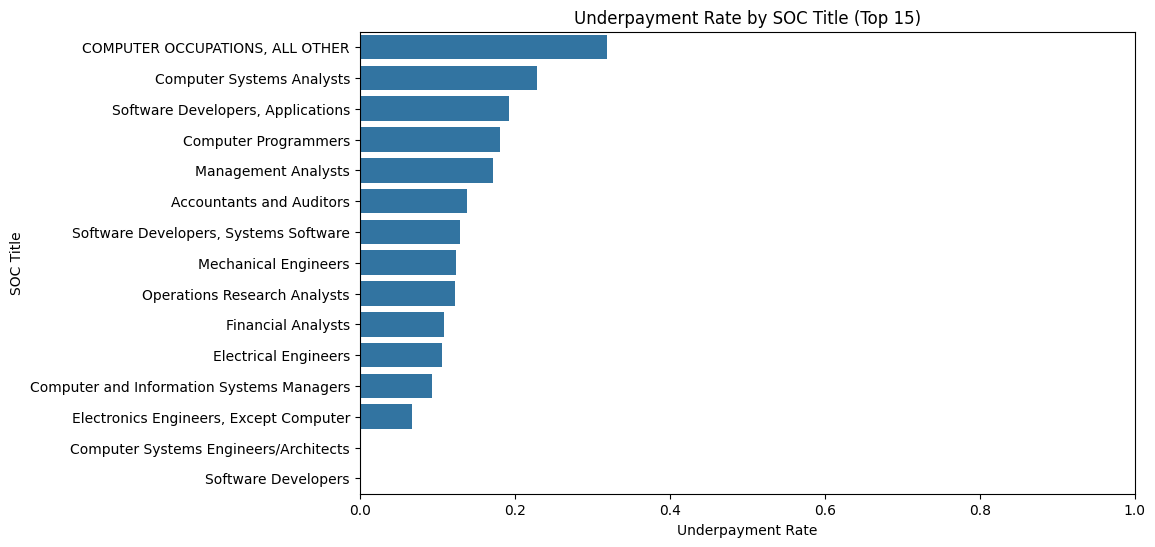

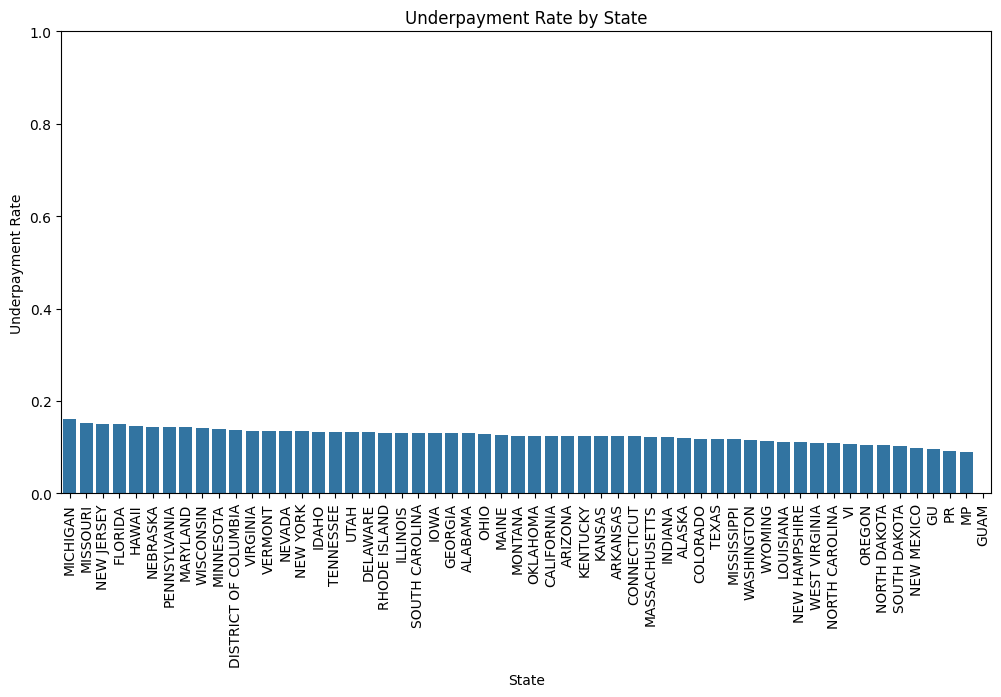

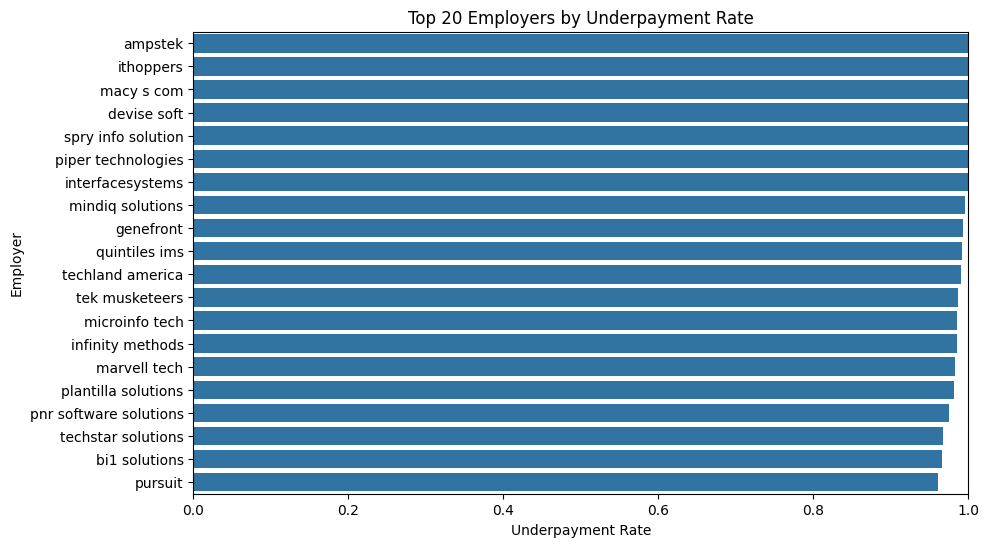

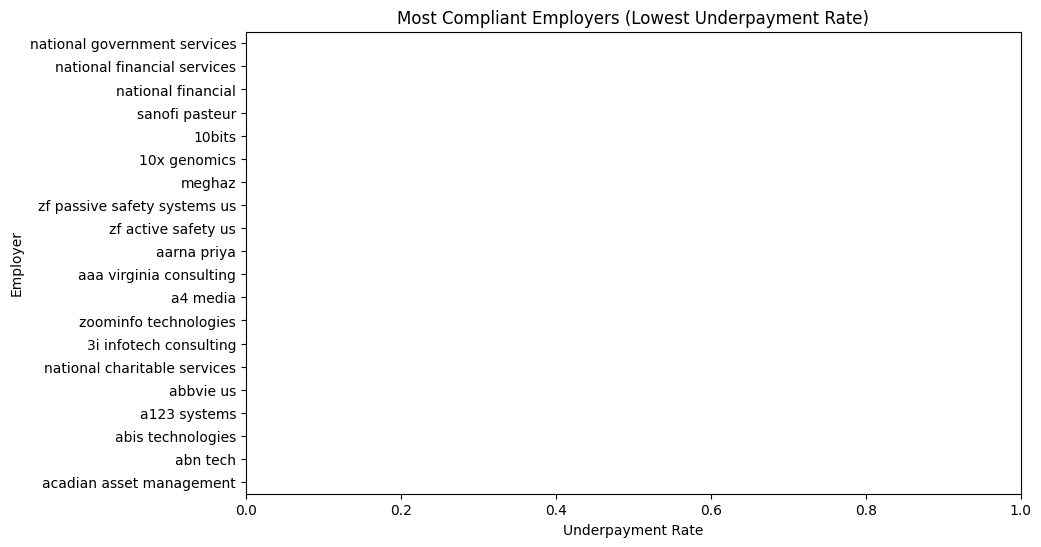

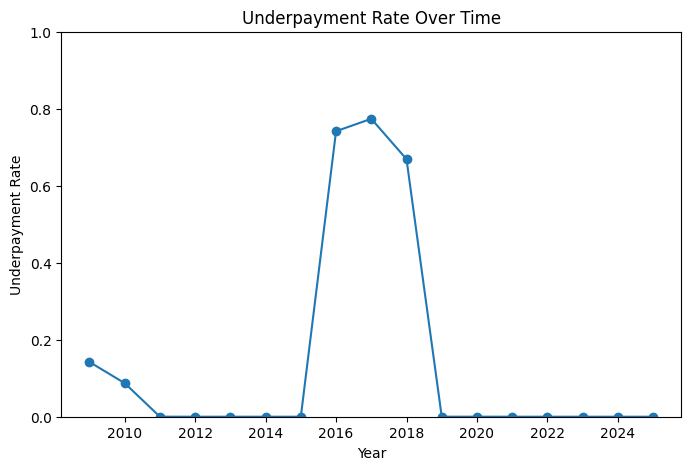

In [ ]:
#DIGGING INTO WAGE GAP
import seaborn as sns

print("Underpayment rate:", (df["wage_ratio"] < 1).mean())

df['underpaid']=(df["wage_ratio"]<1).astype(int)
df["SOC_CODE"] = (
    df["SOC_CODE"]
    .astype(str)
    .str.strip()
    .str.replace(r"\.00$", "", regex=True)  # remove trailing .00 only
)

soc_title_map = (
    df
    .groupby(["SOC_CODE", "SOC_TITLE"])  # change SOC_NAME if needed
    .size()
    .reset_index(name="count")
    .sort_values(["SOC_CODE", "count"], ascending=[True, False])
    .drop_duplicates("SOC_CODE")
    .set_index("SOC_CODE")["SOC_TITLE"]
)

df["SOC_TITLE_CLEAN"] = df["SOC_CODE"].map(soc_title_map)

top_soc = df["SOC_CODE"].value_counts().head(15).index
df_soc = df[df["SOC_CODE"].isin(top_soc)]

soc_rates = (
    df_soc
    .groupby("SOC_TITLE_CLEAN")
    .agg(
        underpay_rate=("underpaid", "mean"),
        n=("underpaid", "size")
    )
    .sort_values("underpay_rate", ascending=False)
)

plt.figure(figsize=(10,6))
sns.barplot(
    x=soc_rates["underpay_rate"],
    y=soc_rates.index
)

plt.title("Underpayment Rate by SOC Title (Top 15)")
plt.xlabel("Underpayment Rate")
plt.ylabel("SOC Title")

plt.xlim(0, 1)
plt.show()

state_counts = df["WORKSITE_STATE"].value_counts()
valid_states = state_counts[state_counts >= 100].index

df_state = df[df["WORKSITE_STATE"].isin(valid_states)]

state_rates = (
    df_state
    .groupby("WORKSITE_STATE")
    .agg(
        underpay_rate=("underpaid", "mean"),
        n=("underpaid", "size")
    )
    .sort_values("underpay_rate", ascending=False)
)

plt.figure(figsize=(12,6))
sns.barplot(
    x=state_rates.index,
    y=state_rates["underpay_rate"]
)

plt.xticks(rotation=90)
plt.title("Underpayment Rate by State")
plt.ylabel("Underpayment Rate")
plt.xlabel("State")

plt.ylim(0, 1)
plt.show()

emp_counts = df["EMPLOYER_NAME_CLEAN"].value_counts()
top_employers = emp_counts[emp_counts >= 100].index  # adjust threshold

df_emp = df[df["EMPLOYER_NAME_CLEAN"].isin(top_employers)]

emp_rates = (
    df_emp
    .groupby("EMPLOYER_NAME_CLEAN")
    .agg(
        underpay_rate=("underpaid", "mean"),
        n=("underpaid", "size")
    )
    .sort_values("underpay_rate", ascending=False)
)

top20 = emp_rates.head(20)

plt.figure(figsize=(10,6))
sns.barplot(
    x=top20["underpay_rate"],
    y=top20.index
)

plt.title("Top 20 Employers by Underpayment Rate")
plt.xlabel("Underpayment Rate")
plt.ylabel("Employer")

plt.xlim(0, 1)
plt.show()

bottom20 = emp_rates.tail(20)

plt.figure(figsize=(10,6))
sns.barplot(
    x=bottom20["underpay_rate"],
    y=bottom20.index
)

plt.title("Most Compliant Employers (Lowest Underpayment Rate)")
plt.xlabel("Underpayment Rate")
plt.ylabel("Employer")

plt.xlim(0, 1)
plt.show()

year_rates = (
    df.groupby("year")
    .agg(
        underpay_rate=("underpaid", "mean"),
        n=("underpaid", "size")
    )
    .sort_index()
)

plt.figure(figsize=(8,5))
plt.plot(year_rates.index, year_rates["underpay_rate"], marker="o")
plt.title("Underpayment Rate Over Time")
plt.xlabel("Year")
plt.ylabel("Underpayment Rate")
plt.ylim(0, 1)
plt.show()

#Since 2019, all wage ratios are >1 since it was an automated system to reject any application with suggested wage < prevailing wage. So we will not 
#detect underpayment directly from reported wage ratio.
#However, underpayment could come from underreporting wage level

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display
import numpy as np

#DATA SUMMARY STATISTICS
state_map = {
    'AL': 'Alabama', 'AK': 'Alaska', 'AZ': 'Arizona', 'AR': 'Arkansas',
    'CA': 'California', 'CO': 'Colorado', 'CT': 'Connecticut', 'DE': 'Delaware',
    'FL': 'Florida', 'GA': 'Georgia', 'HI': 'Hawaii', 'ID': 'Idaho',
    'IL': 'Illinois', 'IN': 'Indiana', 'IA': 'Iowa', 'KS': 'Kansas',
    'KY': 'Kentucky', 'LA': 'Louisiana', 'ME': 'Maine', 'MD': 'Maryland',
    'MA': 'Massachusetts', 'MI': 'Michigan', 'MN': 'Minnesota', 'MS': 'Mississippi',
    'MO': 'Missouri', 'MT': 'Montana', 'NE': 'Nebraska', 'NV': 'Nevada',
    'NH': 'New Hampshire', 'NJ': 'New Jersey', 'NM': 'New Mexico', 'NY': 'New York',
    'NC': 'North Carolina', 'ND': 'North Dakota', 'OH': 'Ohio', 'OK': 'Oklahoma',
    'OR': 'Oregon', 'PA': 'Pennsylvania', 'RI': 'Rhode Island',
    'SC': 'South Carolina', 'SD': 'South Dakota', 'TN': 'Tennessee',
    'TX': 'Texas', 'UT': 'Utah', 'VT': 'Vermont', 'VA': 'Virginia',
    'WA': 'Washington', 'WV': 'West Virginia', 'WI': 'Wisconsin', 'WY': 'Wyoming',
    'DC': 'District of Columbia'
}

df = pd.read_parquet("../data/final_cleaned.parquet")
pd.options.display.float_format = '{:,.2f}'.format
df.WORKSITE_STATE = df.WORKSITE_STATE.map(state_map).fillna(df.WORKSITE_STATE).str.upper()
df = df.dropna(subset=['WAGE_RATE_OF_PAY', 'PREVAILING_WAGE'])  # drop rows with missing wage data
df = df[(df.WAGE_RATE_OF_PAY > 0) & (df.PREVAILING_WAGE > 0)]  # filter out non-positive wages
df = df[df.WAGE_RATE_OF_PAY <10**7]  # filter out likely incorrect wages 
df['log_wage'] = np.log(df['WAGE_RATE_OF_PAY'])
df['wage_ratio'] = df['WAGE_RATE_OF_PAY'] / df['PREVAILING_WAGE']

df["WAGE_LEVEL_CLEAN"] = (
    df["WAGE_LEVEL"]
    .astype(str)
    .str.strip()
    .str.upper()
)

# Map everything to Roman numerals
mapping = {
    "LEVEL I": "I",
    "LEVEL II": "II",
    "LEVEL III": "III",
    "LEVEL IV": "IV",
    "I": "I",
    "II": "II",
    "III": "III",
    "IV": "IV"
}

df["WAGE_LEVEL_CLEAN"] = df["WAGE_LEVEL_CLEAN"].map(mapping)


df.groupby("WAGE_LEVEL")["wage_ratio"].mean()